## ⚠️ Important Analysis Notes

**Genetic Code Table:** This analysis uses **transl_table=5** (Invertebrate Mitochondrial Code)
- ATA = Methionine (M) instead of Isoleucine
- TGA = Tryptophan (W) instead of STOP
- AGA/AGG = Serine (S) instead of Arginine

**Feature Counting:**
- GenBank files contain **both** `gene` features (annotations) AND feature-type entries (`CDS`, `tRNA`, `rRNA`)
- To avoid double-counting, we **only count** `CDS`, `tRNA`, `rRNA`, and `D-loop` features
- We **skip** `gene` annotation features in all analyses

**Expected Counts:**
- 13 protein-coding genes (CDS)
- 22 tRNA genes
- 2 rRNA genes (12S and 16S)
- 1 control region (D-loop)

# Thereuopoda Mitochondrial Genome Analysis
**Genome Size:** 14,900 bp (circular)  
**Organism:** Thereuopoda sp. (Scutigeromorpha: Scutigeridae)  
**Genetic Code:** Invertebrate mitochondrial code (Table 5)

This notebook provides comprehensive analysis of:
- Codon usage patterns (RSCU)
- Amino acid composition
- GC content and skew analysis
- Gene organization and features
- Circular genome visualization

In [1]:
# ==============================================================
# Mitochondrial Genome Codon Usage Analysis (RSCU + Composition)
# Compatible with: Invertebrate mitochondrial genetic code (table 5)
# ==============================================================

# --- Import required packages ---
from Bio import SeqIO
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, Wedge, Circle
import warnings
warnings.filterwarnings('ignore')

# --- Load your annotated GenBank file ---
genbank_file = "sequence_M3509A_corrected.gb"   # <- replace with your filename
record = SeqIO.read(genbank_file, "genbank")

# --- Extract protein-coding sequences (CDS) ---
cds_features = [f for f in record.features if f.type == "CDS"]
codon_counts = Counter()
aa_counts = Counter()

for f in cds_features:
    seq = f.extract(record.seq)
    codons = [str(seq[i:i+3]).upper() for i in range(0, len(seq), 3) if len(seq[i:i+3]) == 3]
    codon_counts.update(codons)
    aa_seq = seq.translate(table=5, to_stop=True)
    aa_counts.update(str(aa_seq))

# --- Define the invertebrate mitochondrial codon table (transl_table=5) ---
codon_table = {
    'TTT':'F','TTC':'F','TTA':'L','TTG':'L','CTT':'L','CTC':'L','CTA':'L','CTG':'L',
    'ATT':'I','ATC':'I','ATA':'M','ATG':'M','GTT':'V','GTC':'V','GTA':'V','GTG':'V',
    'TCT':'S','TCC':'S','TCA':'S','TCG':'S','CCT':'P','CCC':'P','CCA':'P','CCG':'P',
    'ACT':'T','ACC':'T','ACA':'T','ACG':'T','GCT':'A','GCC':'A','GCA':'A','GCG':'A',
    'TAT':'Y','TAC':'Y','CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
    'AAT':'N','AAC':'N','AAA':'K','AAG':'K','GAT':'D','GAC':'D','GAA':'E','GAG':'E',
    'TGT':'C','TGC':'C','TGA':'W','TGG':'W','CGT':'R','CGC':'R','CGA':'R','CGG':'R',
    'AGT':'S','AGC':'S','AGA':'S','AGG':'S','GGT':'G','GGC':'G','GGA':'G','GGG':'G'
}

print("✓ Libraries imported and GenBank file loaded successfully!")
print(f"✓ Genome size: {len(record.seq):,} bp")
print(f"✓ CDS features found: {len(cds_features)}")

✓ Libraries imported and GenBank file loaded successfully!
✓ Genome size: 14,900 bp
✓ CDS features found: 13


In [2]:
# ==============================================================
# Additional Analysis: Genome Statistics Summary
# ==============================================================

genome_stats = {
    "Genome Size (bp)": len(record.seq),
    "Topology": "Circular",
    "Total PCGs": len([f for f in record.features if f.type == "CDS"]),
    "Total tRNAs": len([f for f in record.features if f.type == "tRNA"]),
    "Total rRNAs": len([f for f in record.features if f.type == "rRNA"]),
    "Control Region": len([f for f in record.features if f.type == "D-loop"]),
}

# Calculate overall base composition
full_seq = str(record.seq).upper()
A = full_seq.count("A")
T = full_seq.count("T")
G = full_seq.count("G")
C = full_seq.count("C")
total = A + T + G + C
genome_length = len(record.seq)

genome_stats["A%"] = round((A/total)*100, 2)
genome_stats["T%"] = round((T/total)*100, 2)
genome_stats["G%"] = round((G/total)*100, 2)
genome_stats["C%"] = round((C/total)*100, 2)
genome_stats["GC%"] = round(((G+C)/total)*100, 2)
genome_stats["AT%"] = round(((A+T)/total)*100, 2)
genome_stats["GC Skew"] = round((G-C)/(G+C), 4) if (G+C) > 0 else 0
genome_stats["AT Skew"] = round((A-T)/(A+T), 4) if (A+T) > 0 else 0

print("=" * 60)
print("THEREUOPODA MITOCHONDRIAL GENOME - SUMMARY STATISTICS")
print("=" * 60)
for key, value in genome_stats.items():
    print(f"{key:25s}: {value}")
print("=" * 60)

THEREUOPODA MITOCHONDRIAL GENOME - SUMMARY STATISTICS
Genome Size (bp)         : 14900
Topology                 : Circular
Total PCGs               : 13
Total tRNAs              : 22
Total rRNAs              : 2
Control Region           : 1
A%                       : 34.6
T%                       : 32.12
G%                       : 10.85
C%                       : 22.42
GC%                      : 33.28
AT%                      : 66.72
GC Skew                  : -0.3477
AT Skew                  : 0.0372


In [3]:
# ==============================================================
# Verification: Check for Double-Counting Issues
# ==============================================================

print("\n" + "="*70)
print("FEATURE COUNTING VERIFICATION")
print("="*70)

# Count different feature types
feature_counts = {}
for feature in record.features:
    ftype = feature.type
    if ftype not in feature_counts:
        feature_counts[ftype] = 0
    feature_counts[ftype] += 1

print("\nAll features in GenBank file:")
for ftype, count in sorted(feature_counts.items()):
    print(f"  {ftype:15s}: {count:3d}")

print("\nFeatures used in analysis (excluding 'gene' annotations):")
analysis_features = {k:v for k,v in feature_counts.items() if k != 'gene'}
for ftype, count in sorted(analysis_features.items()):
    print(f"  {ftype:15s}: {count:3d}")

print("\n✓ Using only CDS, tRNA, rRNA, D-loop features (no double-counting)")
print("✓ Using transl_table=5 (Invertebrate Mitochondrial Code)")
print("="*70)


FEATURE COUNTING VERIFICATION

All features in GenBank file:
  CDS            :  13
  D-loop         :   1
  gene           :  37
  rRNA           :   2
  source         :   1
  tRNA           :  22

Features used in analysis (excluding 'gene' annotations):
  CDS            :  13
  D-loop         :   1
  rRNA           :   2
  source         :   1
  tRNA           :  22

✓ Using only CDS, tRNA, rRNA, D-loop features (no double-counting)
✓ Using transl_table=5 (Invertebrate Mitochondrial Code)



RSCU CALCULATION COMPLETE
Total codons analyzed: 4571
Unique amino acids: 20
Total unique codons: 60
RSCU range: 0.199 - 1.898

Top 10 codons by RSCU:
   Codon AminoAcid  Count      RSCU
47   TCT         S    162  1.898438
12   GGA         G     48  1.761468
56   TGA         W     72  1.734940
20   AAA         K    253  1.686667
26   TTA         L    154  1.615385
33   CCC         P     91  1.529412
28   ATA         M    176  1.523810
36   CAA         Q    146  1.520833
8    GAA         E     74  1.480000
55   GTT         V     64  1.479769

Bottom 10 codons by RSCU:
   Codon AminoAcid  Count      RSCU
2    GCG         A      7  0.198582
34   CCG         P     15  0.252101
57   TGG         W     11  0.265060
46   TCG         S     25  0.292969
21   AAG         K     47  0.313333
50   ACG         T     27  0.356436
27   TTG         L     41  0.430070
29   ATG         M     55  0.476190
14   GGG         G     13  0.477064
37   CAG         Q     46  0.479167


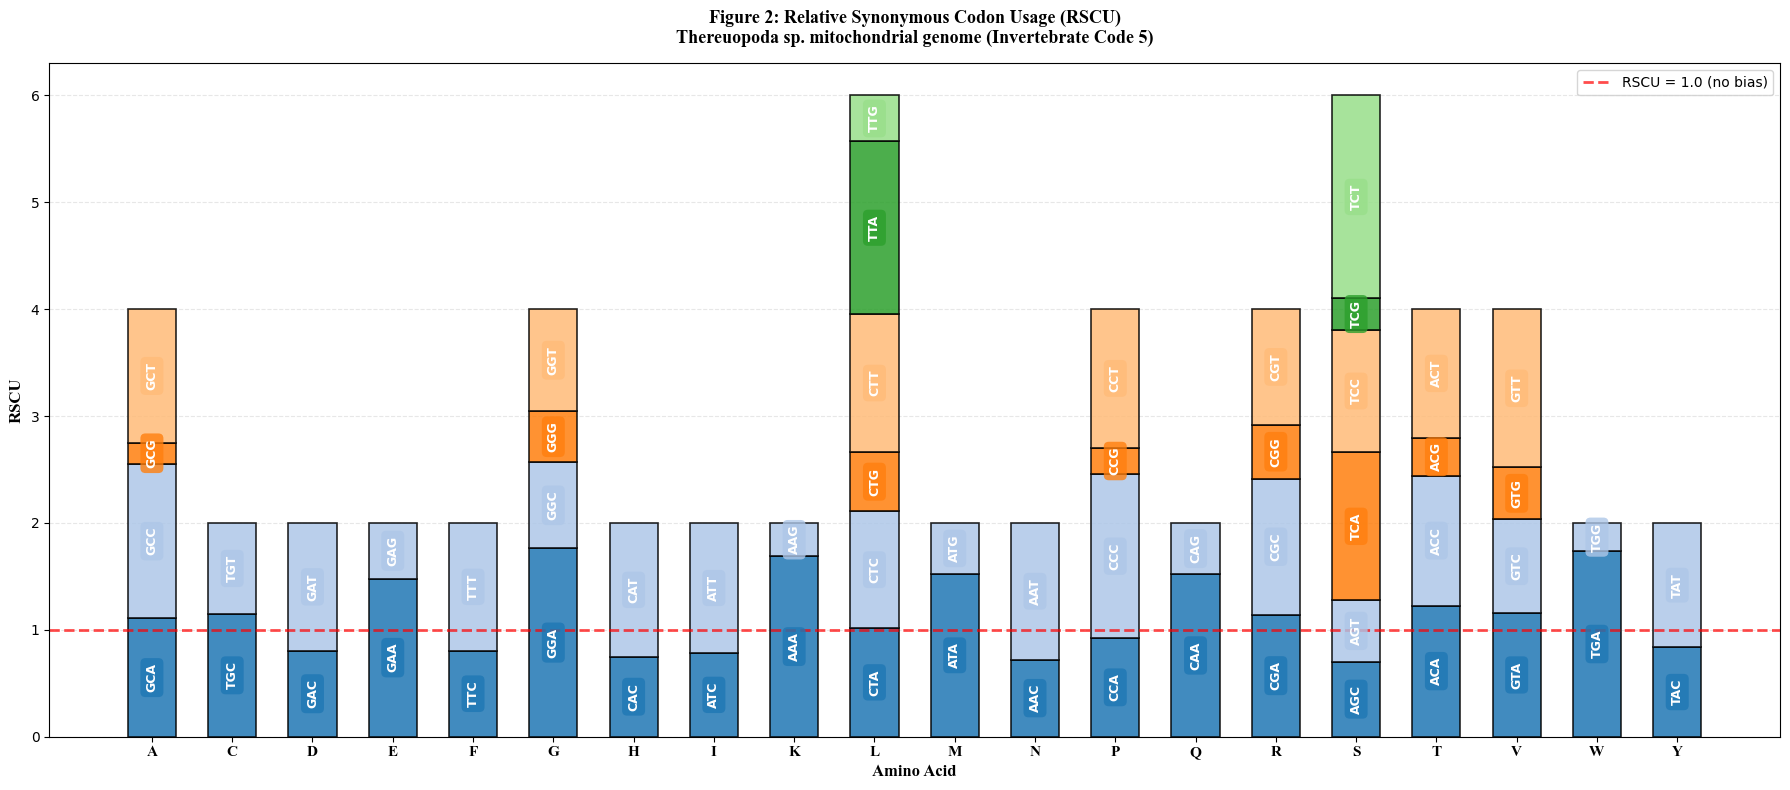


✅ RSCU figure saved successfully!
   - Figure2_RSCU_improved.svg
   - Figure2_RSCU_improved.jpg


In [4]:
# ==============================================================
# RSCU Calculation with Invertebrate Mitochondrial Genetic Code (NCBI Code 5)
# ==============================================================

# Define invertebrate mitochondrial genetic code (NCBI code 5)
stop_codons = ['TAA', 'TAG', 'AGA', 'AGG']

aa_table = {
    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    'ATT': 'I', 'ATC': 'I', 'ATA': 'M',  # ATA codes for M, not I
    'ATG': 'M', 'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'TAT': 'Y', 'TAC': 'Y', 'CAT': 'H', 'CAC': 'H',
    'CAA': 'Q', 'CAG': 'Q', 'AAT': 'N', 'AAC': 'N',
    'AAA': 'K', 'AAG': 'K', 'GAT': 'D', 'GAC': 'D',
    'GAA': 'E', 'GAG': 'E', 'TGT': 'C', 'TGC': 'C',
    'TGA': 'W',  # TGA codes for W, not stop
    'TGG': 'W', 'CGT': 'R', 'CGC': 'R', 'CGA': 'R',
    'CGG': 'R', 'AGT': 'S', 'AGC': 'S', 'GGT': 'G',
    'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
}

# Function to compute RSCU with improved accuracy
def compute_rscu_improved(seq_str):
    """
    Compute Relative Synonymous Codon Usage (RSCU)
    for invertebrate mitochondrial genomes (NCBI code 5)
    """
    # Clean sequence
    seq_str = seq_str.upper().replace("\n", "").replace(" ", "")
    
    # Extract codons (reading frame 0)
    codons = [seq_str[i:i+3].upper() for i in range(0, len(seq_str)-2, 3)]
    
    # Count only valid codons (those in aa_table)
    codon_counts = Counter([c for c in codons if c in aa_table])
    
    # Map amino acid to all possible codons
    aa_to_codons = defaultdict(list)
    for codon, aa in aa_table.items():
        aa_to_codons[aa].append(codon)
    
    # Compute RSCU for each codon
    rscu = {}
    for aa, codon_list in aa_to_codons.items():
        total = sum(codon_counts[c] for c in codon_list)
        n = len(codon_list)  # number of synonymous codons for this AA
        
        for codon in codon_list:
            obs = codon_counts[codon]  # observed count
            exp = total / n if n > 0 else 0  # expected count
            rscu[codon] = obs / exp if exp > 0 else 0
    
    # Create DataFrame
    df = pd.DataFrame(list(rscu.items()), columns=["Codon", "RSCU"])
    df["AminoAcid"] = df["Codon"].map(lambda c: aa_table.get(c, 'X'))
    df["Count"] = df["Codon"].map(lambda c: codon_counts.get(c, 0))
    df = df.sort_values(["AminoAcid", "Codon"]).reset_index(drop=True)
    
    return df

# Compute RSCU with improved function
df_rscu_plot = compute_rscu_improved(str(full_seq))

print("\n" + "="*80)
print("RSCU CALCULATION COMPLETE")
print("="*80)
print(f"Total codons analyzed: {df_rscu_plot['Count'].sum():.0f}")
print(f"Unique amino acids: {len(df_rscu_plot['AminoAcid'].unique())}")
print(f"Total unique codons: {len(df_rscu_plot)}")
print(f"RSCU range: {df_rscu_plot['RSCU'].min():.3f} - {df_rscu_plot['RSCU'].max():.3f}")
print("="*80)
print("\nTop 10 codons by RSCU:")
print(df_rscu_plot.nlargest(10, 'RSCU')[['Codon', 'AminoAcid', 'Count', 'RSCU']])
print("\nBottom 10 codons by RSCU:")
print(df_rscu_plot.nsmallest(10, 'RSCU')[['Codon', 'AminoAcid', 'Count', 'RSCU']])

# ==============================================================
# Figure 2: Stacked RSCU Chart Grouped by Amino Acid
# ==============================================================

fig, ax = plt.subplots(figsize=(18, 8))
aa_groups = df_rscu_plot.groupby("AminoAcid")
colors = plt.cm.tab20.colors

aa_names = []
x_positions = []
x_pos = 0

for i, (aa, group) in enumerate(aa_groups):
    aa_names.append(aa)
    x_positions.append(x_pos)
    bottom = 0
    
    for j, (idx, row) in enumerate(group.iterrows()):
        codon = row["Codon"]
        rscu_val = row["RSCU"]
        color = colors[j % len(colors)]
        
        # Draw bar segment
        ax.bar(x_pos, rscu_val, bottom=bottom, color=color, edgecolor='black', 
               linewidth=1.2, width=0.6, alpha=0.85)
        
        # Add codon label inside colored segment
        if rscu_val > 0.1:  # Only label if segment is large enough
            ax.text(x_pos, bottom + rscu_val / 2, codon, ha='center', va='center',
                    rotation=90, fontsize=9, color='white', fontweight='bold',
                    bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.4',
                             alpha=0.8))
        
        bottom += rscu_val
    
    x_pos += 1

# Formatting
ax.axhline(1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='RSCU = 1.0 (no bias)')
ax.set_xticks(x_positions)
ax.set_xticklabels(aa_names, fontsize=11, fontweight='bold', fontfamily='Times New Roman')
ax.set_ylabel("RSCU", fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_xlabel("Amino Acid", fontsize=12, fontweight='bold', fontfamily='Times New Roman')
ax.set_title("Figure 2: Relative Synonymous Codon Usage (RSCU)\nThereuopoda sp. mitochondrial genome (Invertebrate Code 5)",
            fontsize=13, fontweight='bold', fontfamily='Times New Roman', pad=15)

# Add grid
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc='upper right', fontsize=10)

# Adjust layout and save
plt.tight_layout()
plt.savefig('Figure2_RSCU_improved.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('Figure2_RSCU_improved.jpg', format='jpg', dpi=600, bbox_inches='tight', 
            pil_kwargs={'quality': 95})
plt.show()

print("\n✅ RSCU figure saved successfully!")
print("   - Figure2_RSCU_improved.svg")
print("   - Figure2_RSCU_improved.jpg")


RSCU CALCULATION COMPLETE (CDS-ONLY, GENE-BY-GENE)
CDS features used: 13
Total CDS nucleotides: 11063
Trailing nucleotides dropped (incomplete codons): 5
Total codons analyzed: 3686
Unique amino acids: 21
Total unique codons: 64
RSCU range: 0.112 - 2.487

Top 10 codons by RSCU:
   Codon AA  Count      RSCU
49   TCT  S    111  2.487395
30   TTA  L    195  2.074468
41   CCT  P     69  2.029412
18   GGA  G    101  1.819820
56   TGA  W     90  1.714286
55   ACT  T     75  1.694915
13   TGT  C     32  1.684211
3    GCT  A     80  1.658031
4    CGA  R     24  1.655172
42   AGA  S     72  1.613445

Bottom 10 codons by RSCU:
   Codon AA  Count      RSCU
48   TCG  S      5  0.112045
40   CCG  P      4  0.117647
54   ACG  T      7  0.158192
44   AGG  S     10  0.224090
2    GCG  A     12  0.248705
5    CGC  R      4  0.275862
57   TGG  W     15  0.285714
43   AGC  S     14  0.313725
12   TGC  C      6  0.315789
28   CTG  L     30  0.319149


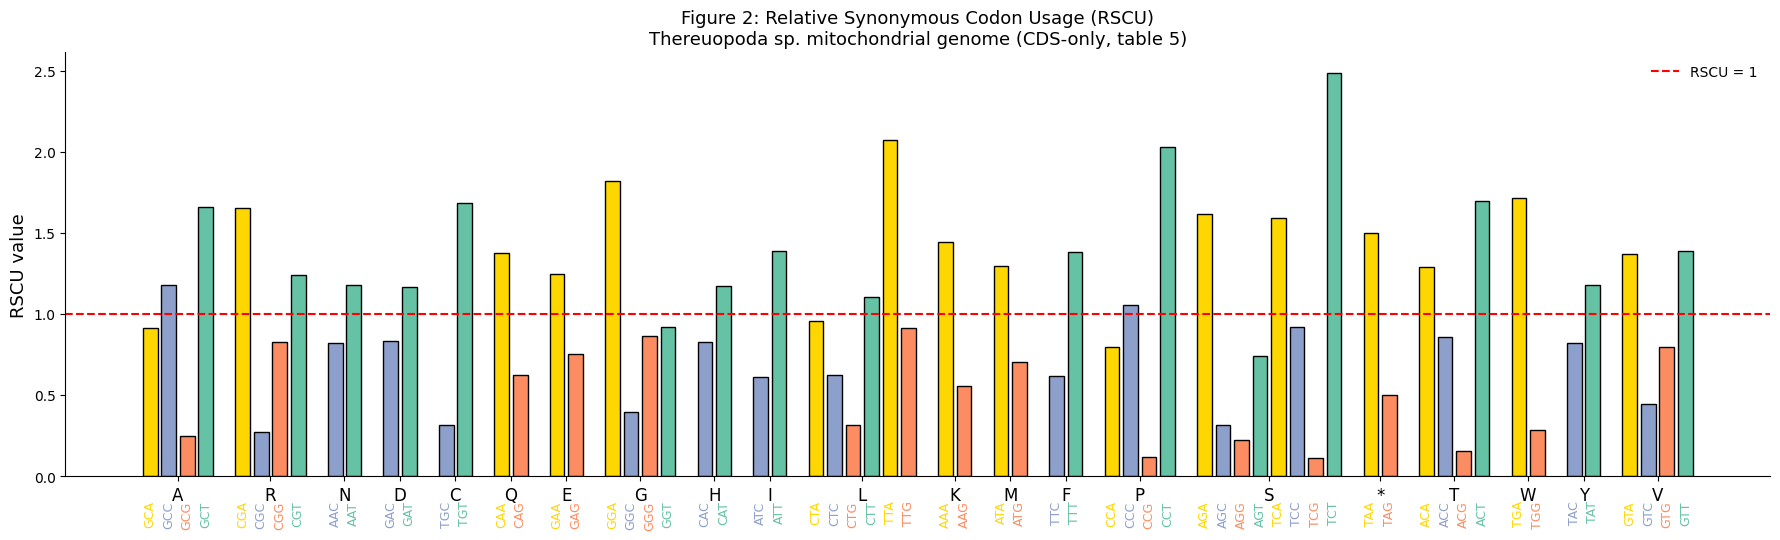

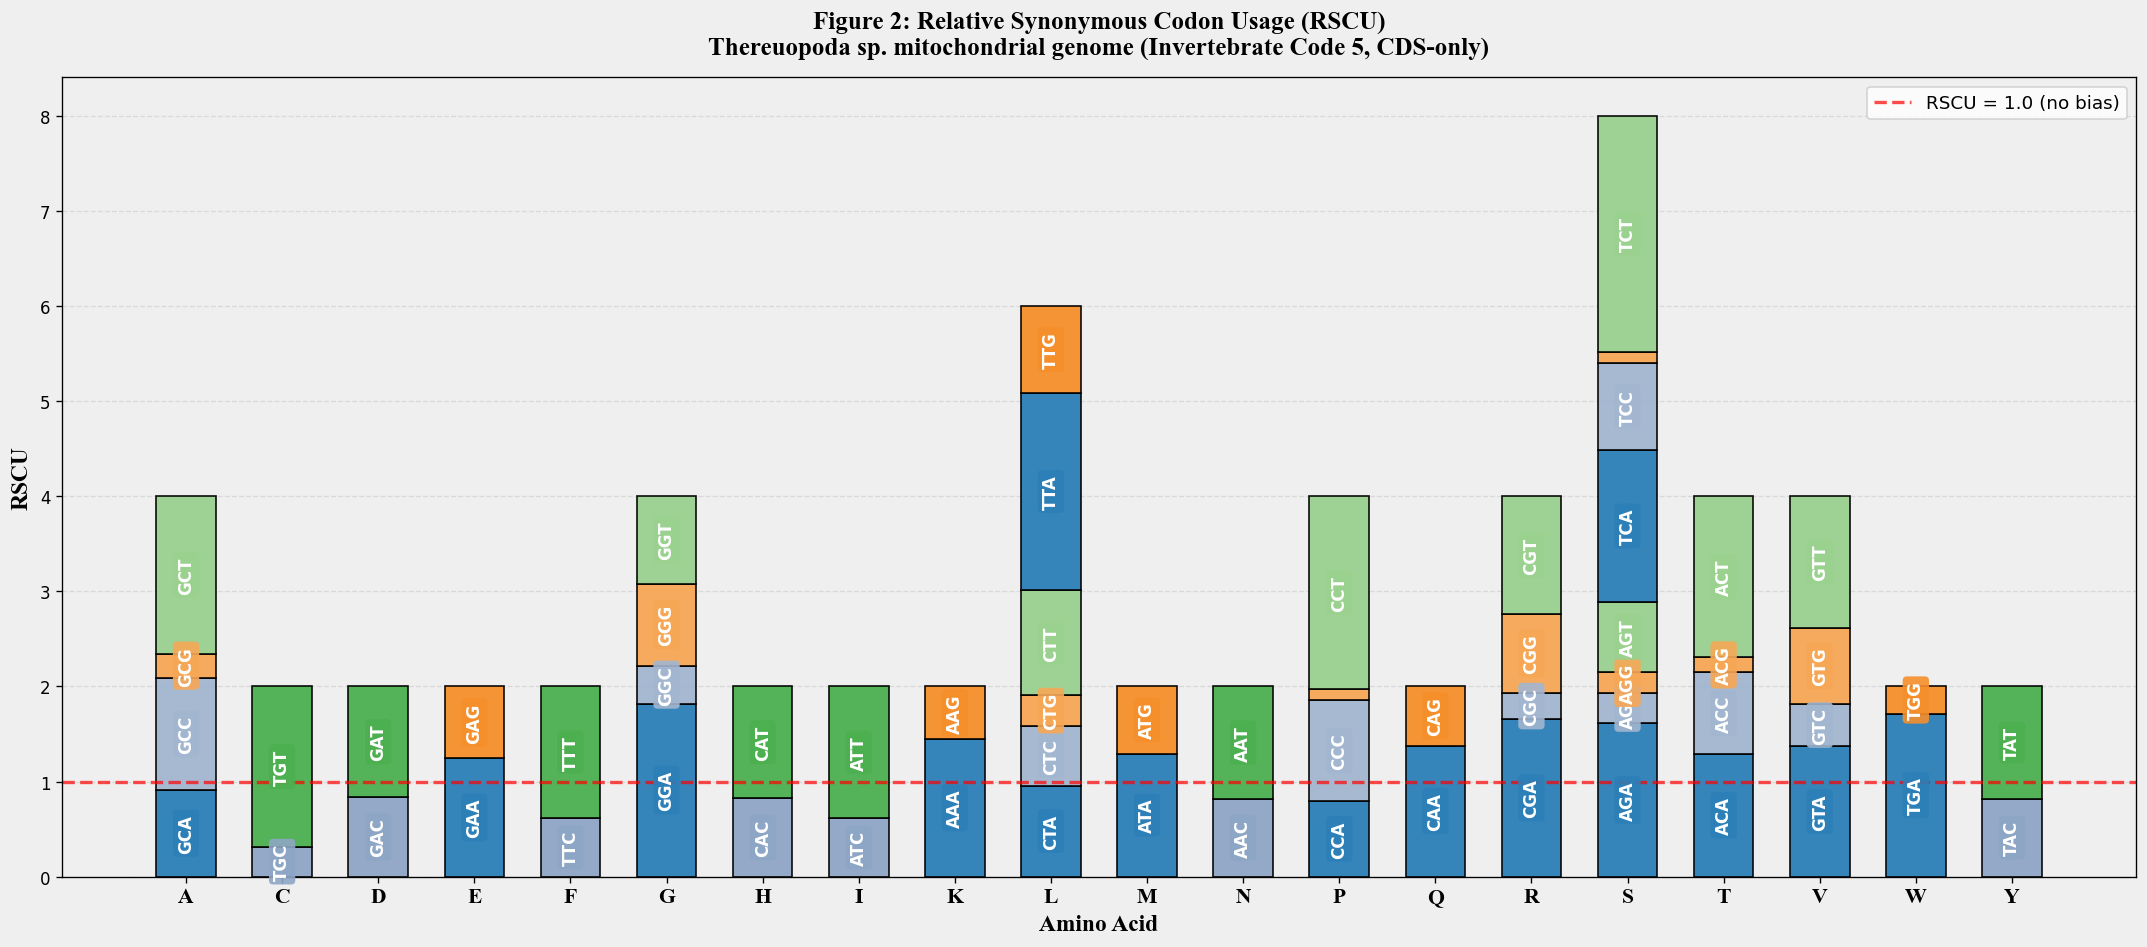

<Figure size 640x480 with 0 Axes>

In [5]:
# ==============================================================
# Figure 2: RSCU from CDS only (13 mitochondrial PCGs) - Corrected
# Invertebrate mitochondrial genetic code (NCBI table 5)
# ==============================================================

from Bio.Data import CodonTable
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt

# 1) Build codon table (include stop codons as "*")
table = CodonTable.unambiguous_dna_by_id[5]
aa_table = table.forward_table.copy()
for stop in table.stop_codons:
    aa_table[stop] = "*"

# 2) Count codons CDS-by-CDS (NOT whole genome)
codon_counts = Counter()
cds_count = 0
total_cds_nt = 0
dropped_nt = 0

for feature in record.features:
    if feature.type != "CDS":
        continue

    cds_count += 1
    seq = str(feature.extract(record.seq)).upper().replace("\n", "").replace(" ", "")
    total_cds_nt += len(seq)

    # Keep only complete codons per CDS; discard trailing partial codon(s)
    usable_len = (len(seq) // 3) * 3
    dropped_nt += (len(seq) - usable_len)

    codons = [seq[i:i+3] for i in range(0, usable_len, 3)]
    codon_counts.update([c for c in codons if c in aa_table])

# 3) Group codons by amino acid
aa_to_codons = defaultdict(list)
for codon, aa in aa_table.items():
    aa_to_codons[aa].append(codon)

# 4) Compute RSCU
records = []
for aa, codon_list in aa_to_codons.items():
    total = sum(codon_counts[c] for c in codon_list)
    n = len(codon_list)

    for codon in codon_list:
        obs = codon_counts[codon]
        exp = (total / n) if total > 0 else 0
        rscu = (obs / exp) if exp > 0 else 0
        records.append([aa, codon, obs, rscu])

df_rscu_plot = pd.DataFrame(records, columns=["AA", "Codon", "Count", "RSCU"])

# 5) Amino-acid order for plotting (includes stop)
aa_order = [
    "A","R","N","D","C","Q","E","G","H","I",
    "L","K","M","F","P","S","*","T","W","Y","V"
]
df_rscu_plot["AA"] = pd.Categorical(df_rscu_plot["AA"], categories=aa_order, ordered=True)
df_rscu_plot = df_rscu_plot.sort_values(["AA", "Codon"]).reset_index(drop=True)

# 6) Report summary
print("\n" + "="*80)
print("RSCU CALCULATION COMPLETE (CDS-ONLY, GENE-BY-GENE)")
print("="*80)
print(f"CDS features used: {cds_count}")
print(f"Total CDS nucleotides: {total_cds_nt}")
print(f"Trailing nucleotides dropped (incomplete codons): {dropped_nt}")
print(f"Total codons analyzed: {df_rscu_plot['Count'].sum():.0f}")
print(f"Unique amino acids: {len(df_rscu_plot['AA'].unique())}")
print(f"Total unique codons: {len(df_rscu_plot)}")
print(f"RSCU range: {df_rscu_plot['RSCU'].min():.3f} - {df_rscu_plot['RSCU'].max():.3f}")
print("="*80)

print("\nTop 10 codons by RSCU:")
print(df_rscu_plot.nlargest(10, "RSCU")[["Codon", "AA", "Count", "RSCU"]])
print("\nBottom 10 codons by RSCU:")
print(df_rscu_plot.nsmallest(10, "RSCU")[["Codon", "AA", "Count", "RSCU"]])

# 7) Plot (same style as your per-codon chart)
base_colors = {
    "A": "#FFD700",  # yellow
    "T": "#66C2A5",  # green
    "G": "#FC8D62",  # orange/red
    "C": "#8DA0CB"   # blue/purple
}

fig, ax = plt.subplots(figsize=(22, 8))

x = 0
xticks = []
xlabels = []

for aa in aa_order:
    subset = df_rscu_plot[df_rscu_plot["AA"] == aa]
    if subset.empty:
        continue

    for _, row in subset.iterrows():
        codon = row["Codon"]
        ax.bar(
            x,
            row["RSCU"],
            color=base_colors[codon[-1]],
            edgecolor="black",
            width=0.8
        )
        ax.text(
            x,
            -0.15,
            codon,
            ha="center",
            va="top",
            rotation=90,
            fontsize=9,
            color=base_colors[codon[-1]]
        )
        x += 1

    xticks.append(x - len(subset)/2 - 0.5)
    xlabels.append(aa)
    x += 1  # space between amino acids

ax.axhline(1, color="red", linestyle="--", linewidth=1.5, label="RSCU = 1")
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize=12)
ax.set_ylabel("RSCU value", fontsize=13)
ax.set_title("Figure 2: Relative Synonymous Codon Usage (RSCU)\nThereuopoda sp. mitochondrial genome (CDS-only, table 5)", fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.subplots_adjust(bottom=0.35)
plt.legend(frameon=False)# 7) Plot as stacked RSCU bars by amino acid (style like your reference image)
import numpy as np
import matplotlib.pyplot as plt

# Keep stop out of the x-axis to match your example figure
aa_order_plot = ["A","C","D","E","F","G","H","I","K","L","M","N","P","Q","R","S","T","V","W","Y"]

# Third-base color families (blue C/A, orange G, green T), close to your reference
base_palette = {
    "A": ["#2C7FB8", "#4A90C2", "#70A8CC", "#9DB7D2"],
    "C": ["#8EA6C5", "#A2B6D0", "#B8C8DC", "#CFD9E8"],
    "G": ["#F57C00", "#F68F2B", "#F7A756", "#F2BE8A"],
    "T": ["#2CA02C", "#4CAF50", "#77C977", "#9AD18F"]
}

fig, ax = plt.subplots(figsize=(18, 8), dpi=120)
ax.set_facecolor("#efefef")
fig.patch.set_facecolor("#efefef")

x_positions = []
x_labels = []

x = 0
for aa in aa_order_plot:
    subset = df_rscu_plot[df_rscu_plot["AA"] == aa].copy()
    if subset.empty:
        continue

    subset = subset.sort_values("Codon").reset_index(drop=True)
    bottom = 0.0

    for i, row in subset.iterrows():
        codon = row["Codon"]
        rscu_val = float(row["RSCU"])
        third = codon[-1]
        color_list = base_palette.get(third, ["#bbbbbb"])
        color = color_list[i % len(color_list)]

        ax.bar(
            x,
            rscu_val,
            bottom=bottom,
            width=0.62,
            color=color,
            edgecolor="black",
            linewidth=1.0,
            alpha=0.95
        )

        # Label codons inside segments when tall enough
        if rscu_val >= 0.12:
            ax.text(
                x,
                bottom + rscu_val / 2,
                codon,
                ha="center",
                va="center",
                rotation=90,
                fontsize=10,
                color="white",
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor=color,
                    edgecolor="none",
                    alpha=0.9
                )
            )

        bottom += rscu_val

    x_positions.append(x)
    x_labels.append(aa)
    x += 1

# Reference line
ax.axhline(1.0, color="red", linestyle="--", linewidth=2.0, alpha=0.7, label="RSCU = 1.0 (no bias)")

# Axes and title styling
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=13, fontweight="bold", fontfamily="Times New Roman")
ax.set_xlabel("Amino Acid", fontsize=14, fontweight="bold", fontfamily="Times New Roman")
ax.set_ylabel("RSCU", fontsize=14, fontweight="bold", fontfamily="Times New Roman")
ax.set_title(
    "Figure 2: Relative Synonymous Codon Usage (RSCU)\n"
    "Thereuopoda sp. mitochondrial genome (Invertebrate Code 5, CDS-only)",
    fontsize=15,
    fontweight="bold",
    fontfamily="Times New Roman",
    pad=14
)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper right", fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig("Figure2_RSCU_CDS_only_stacked_like_reference.svg", format="svg", dpi=300, bbox_inches="tight")
plt.savefig("Figure2_RSCU_CDS_only_stacked_like_reference.jpg", format="jpg", dpi=600, bbox_inches="tight", pil_kwargs={"quality": 95})
plt.show()
plt.tight_layout()
plt.savefig("Figure2_RSCU_corrected_CDS_only.svg", format="svg", dpi=300, bbox_inches="tight")
plt.savefig("Figure2_RSCU_corrected_CDS_only.jpg", format="jpg", dpi=600, bbox_inches="tight", pil_kwargs={"quality": 95})
plt.show()

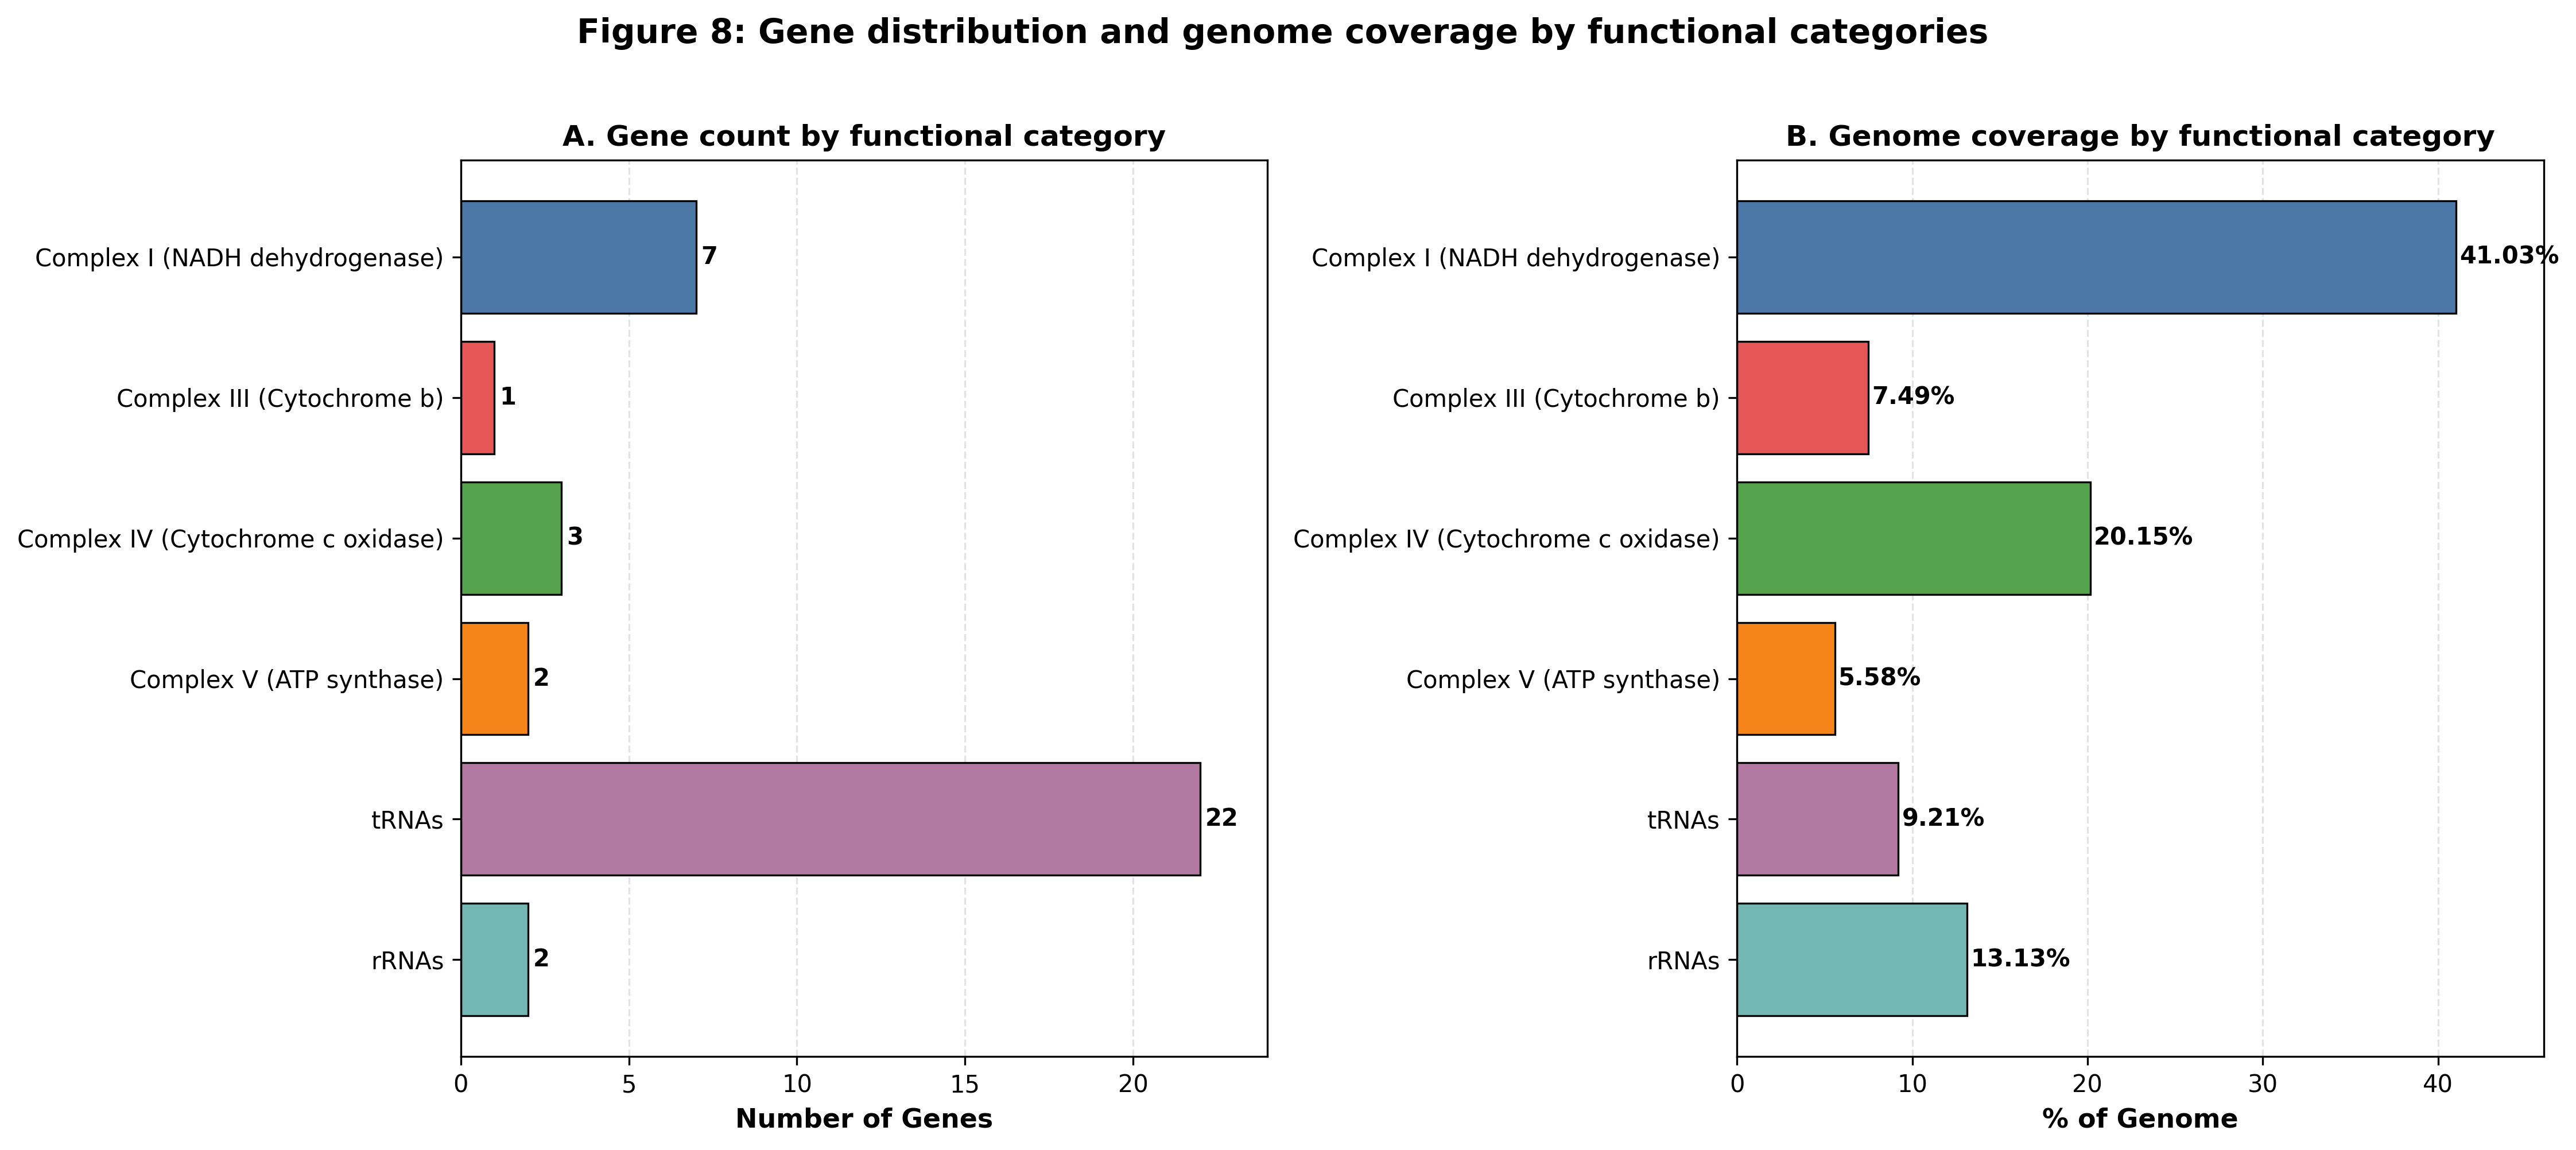


Detailed Gene Category Statistics:
                         Category  Count  Total Length (bp)  % of Genome
   Complex I (NADH dehydrogenase)      7               6114        41.03
       Complex III (Cytochrome b)      1               1116         7.49
Complex IV (Cytochrome c oxidase)      3               3002        20.15
         Complex V (ATP synthase)      2                831         5.58
                            tRNAs     22               1372         9.21
                            rRNAs      2               1956        13.13


In [6]:
# ==============================================================
# Figure 8: Comparative Analysis - Gene Categories
# ==============================================================

import pandas as pd
import matplotlib.pyplot as plt

def normalize_gene_name(name):
    if not name:
        return ""

    g = str(name).strip().upper()
    g = g.replace(" ", "").replace("-", "").replace("_", "")

    synonyms = {
        "ND1": "NAD1", "NAD1": "NAD1",
        "ND2": "NAD2", "NAD2": "NAD2",
        "ND3": "NAD3", "NAD3": "NAD3",
        "ND4": "NAD4", "NAD4": "NAD4",
        "ND4L": "NAD4L", "NAD4L": "NAD4L",
        "ND5": "NAD5", "NAD5": "NAD5",
        "ND6": "NAD6", "NAD6": "NAD6",

        "CYTB": "COB", "COB": "COB",

        "COX1": "COX1", "COI": "COX1",
        "COX2": "COX2", "COII": "COX2",
        "COX3": "COX3", "COIII": "COX3",

        "ATP6": "ATP6",
        "ATP8": "ATP8",

        "12S": "RRNS", "RRNS": "RRNS", "SRRNA": "RRNS",
        "16S": "RRNL", "RRNL": "RRNL", "LRRNA": "RRNL",
    }

    return synonyms.get(g, g)

gene_categories = {
    "Complex I (NADH dehydrogenase)": {"NAD1", "NAD2", "NAD3", "NAD4", "NAD4L", "NAD5", "NAD6"},
    "Complex III (Cytochrome b)": {"COB"},
    "Complex IV (Cytochrome c oxidase)": {"COX1", "COX2", "COX3"},
    "Complex V (ATP synthase)": {"ATP6", "ATP8"},
    "tRNAs": None,
    "rRNAs": None
}

genome_size = len(record.seq)
category_stats = []

for category, genes in gene_categories.items():
    total_length = 0
    gene_count = 0

    for feature in record.features:
        if feature.type == "gene":
            continue

        feature_len = len(feature.extract(record.seq))

        if category == "tRNAs":
            if feature.type == "tRNA":
                total_length += feature_len
                gene_count += 1

        elif category == "rRNAs":
            if feature.type == "rRNA":
                total_length += feature_len
                gene_count += 1

        elif feature.type == "CDS" and genes is not None:
            raw_name = feature.qualifiers.get("gene", [""])[0]
            gene_name = normalize_gene_name(raw_name)

            if gene_name in genes:
                total_length += feature_len
                gene_count += 1

    category_stats.append({
        "Category": category,
        "Count": gene_count,
        "Total Length (bp)": total_length,
        "% of Genome": round((total_length / genome_size) * 100, 2)
    })

df_categories = pd.DataFrame(category_stats)

category_order = [
    "Complex I (NADH dehydrogenase)",
    "Complex III (Cytochrome b)",
    "Complex IV (Cytochrome c oxidase)",
    "Complex V (ATP synthase)",
    "tRNAs",
    "rRNAs"
]
df_categories["Category"] = pd.Categorical(
    df_categories["Category"],
    categories=category_order,
    ordered=True
)
df_categories = df_categories.sort_values("Category").reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), dpi=300)

colors_cat = ['#4C78A8', '#E45756', '#54A24B', '#F58518', '#B279A2', '#72B7B2']

bars1 = ax1.barh(
    df_categories["Category"],
    df_categories["Count"],
    color=colors_cat,
    edgecolor='black',
    linewidth=0.8
)
ax1.set_xlabel("Number of Genes", fontsize=11, fontweight='bold')
ax1.set_title("A. Gene count by functional category", fontsize=12, fontweight='bold')
ax1.grid(axis='x', linestyle='--', alpha=0.35)
ax1.set_axisbelow(True)
ax1.invert_yaxis()
ax1.set_xlim(0, max(df_categories["Count"]) + 2)

for bar, count in zip(bars1, df_categories["Count"]):
    ax1.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{count}",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

bars2 = ax2.barh(
    df_categories["Category"],
    df_categories["% of Genome"],
    color=colors_cat,
    edgecolor='black',
    linewidth=0.8
)
ax2.set_xlabel("% of Genome", fontsize=11, fontweight='bold')
ax2.set_title("B. Genome coverage by functional category", fontsize=12, fontweight='bold')
ax2.grid(axis='x', linestyle='--', alpha=0.35)
ax2.set_axisbelow(True)
ax2.invert_yaxis()
ax2.set_xlim(0, max(df_categories["% of Genome"]) + 5)

for bar, pct in zip(bars2, df_categories["% of Genome"]):
    ax2.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.2f}%",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

fig.suptitle(
    "Figure 8: Gene distribution and genome coverage by functional categories",
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

print("\nDetailed Gene Category Statistics:")
print("=" * 75)
print(df_categories.to_string(index=False))
print("=" * 75)

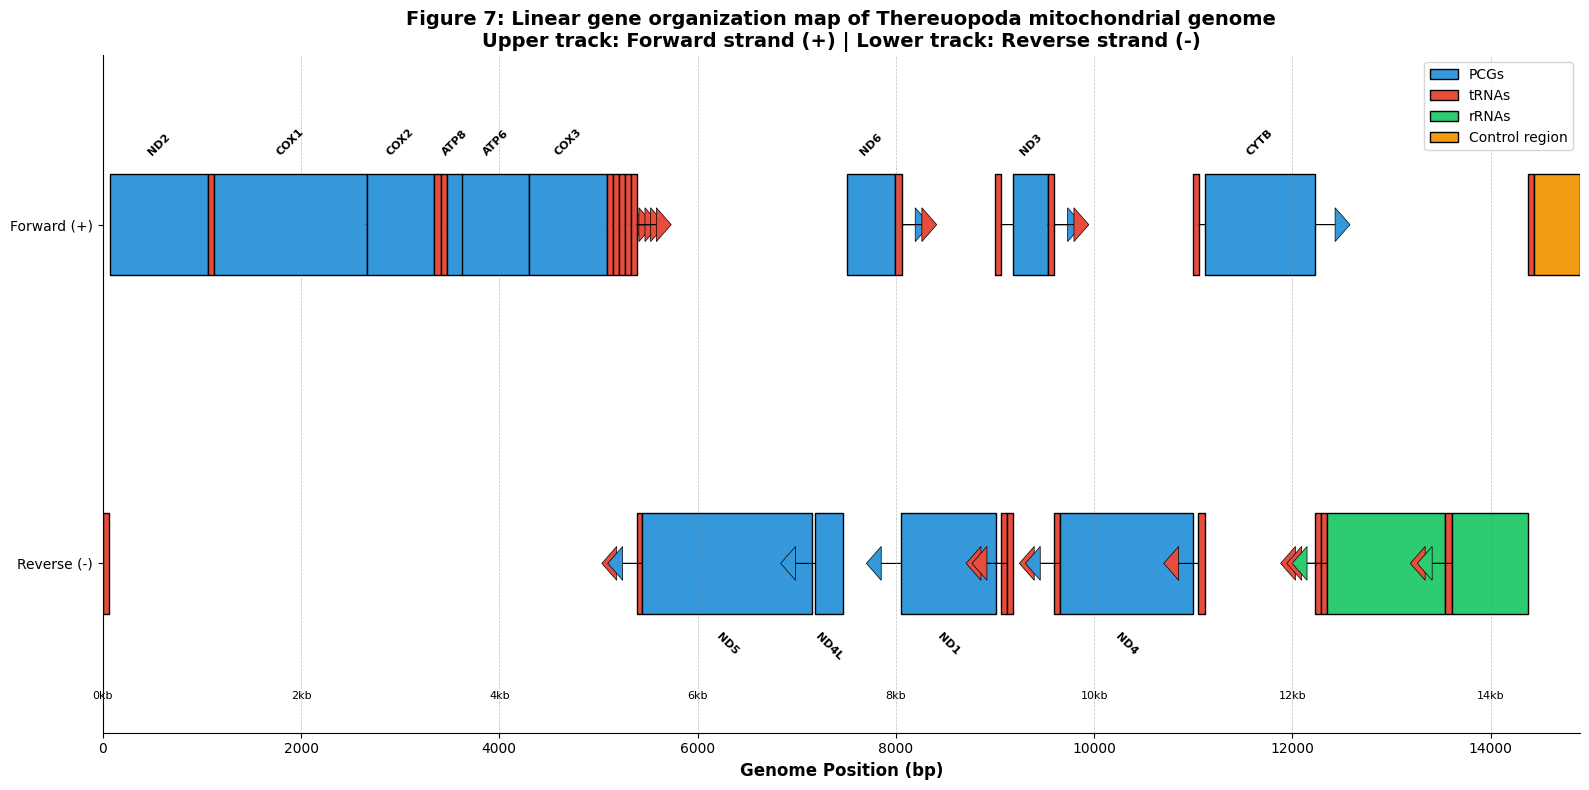

In [7]:
# ==============================================================
# Figure 7: Gene Organization Linear Map
# ==============================================================

fig, ax = plt.subplots(figsize=(16, 8))

# Gene position data
gene_data = []
for feature in record.features:
    if feature.type in ["CDS", "tRNA", "rRNA", "D-loop"]:
        start = int(feature.location.start)
        end = int(feature.location.end)
        gene_name = feature.qualifiers.get("gene", ["unknown"])[0]
        product = feature.qualifiers.get("product", [""])[0]
        strand = feature.strand
        gene_type = feature.type
        
        gene_data.append({
            "start": start, "end": end, "name": gene_name, 
            "product": product, "strand": strand, "type": gene_type
        })

# Color mapping
type_colors = {
    "CDS": "#3498db",
    "tRNA": "#e74c3c", 
    "rRNA": "#2ecc71",
    "D-loop": "#f39c12"
}

# Draw genes
y_forward = 1.5
y_reverse = 0.5

for gene in gene_data:
    color = type_colors.get(gene["type"], "#95a5a6")
    y_pos = y_forward if gene["strand"] == 1 else y_reverse
    width = gene["end"] - gene["start"]
    
    # Draw rectangle for gene
    rect = Rectangle((gene["start"], y_pos - 0.15), width, 0.3, 
                     facecolor=color, edgecolor='black', linewidth=1)
    ax.add_patch(rect)
    
    # Add arrow to indicate direction
    arrow_x = gene["end"] if gene["strand"] == 1 else gene["start"]
    arrow_dx = 200 if gene["strand"] == 1 else -200
    ax.arrow(arrow_x, y_pos, arrow_dx, 0, head_width=0.1, head_length=150, 
            fc=color, ec='black', linewidth=0.5)
    
    # Add gene name
    mid_x = (gene["start"] + gene["end"]) / 2
    if gene["type"] == "CDS":
        rotation = 45 if gene["strand"] == 1 else -45
        va = 'bottom' if gene["strand"] == 1 else 'top'
        y_text = y_pos + 0.2 if gene["strand"] == 1 else y_pos - 0.2
        ax.text(mid_x, y_text, gene["name"], rotation=rotation, 
               ha='center', va=va, fontsize=8, fontweight='bold')

# Styling
ax.set_xlim(0, genome_length)
ax.set_ylim(0, 2)
ax.set_xlabel('Genome Position (bp)', fontsize=12, fontweight='bold')
ax.set_title('Figure 7: Linear gene organization map of Thereuopoda mitochondrial genome\n' +
             'Upper track: Forward strand (+) | Lower track: Reverse strand (-)', 
             fontsize=14, fontweight='bold')

# Add scale bar
scale_interval = 2000
for pos in range(0, genome_length, scale_interval):
    ax.axvline(pos, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.text(pos, 0.1, f'{pos//1000}kb', ha='center', fontsize=8)

ax.set_yticks([y_reverse, y_forward])
ax.set_yticklabels(['Reverse (-)', 'Forward (+)'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=type_colors["CDS"], edgecolor='black', label='PCGs'),
    mpatches.Patch(facecolor=type_colors["tRNA"], edgecolor='black', label='tRNAs'),
    mpatches.Patch(facecolor=type_colors["rRNA"], edgecolor='black', label='rRNAs'),
    mpatches.Patch(facecolor=type_colors["D-loop"], edgecolor='black', label='Control region')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

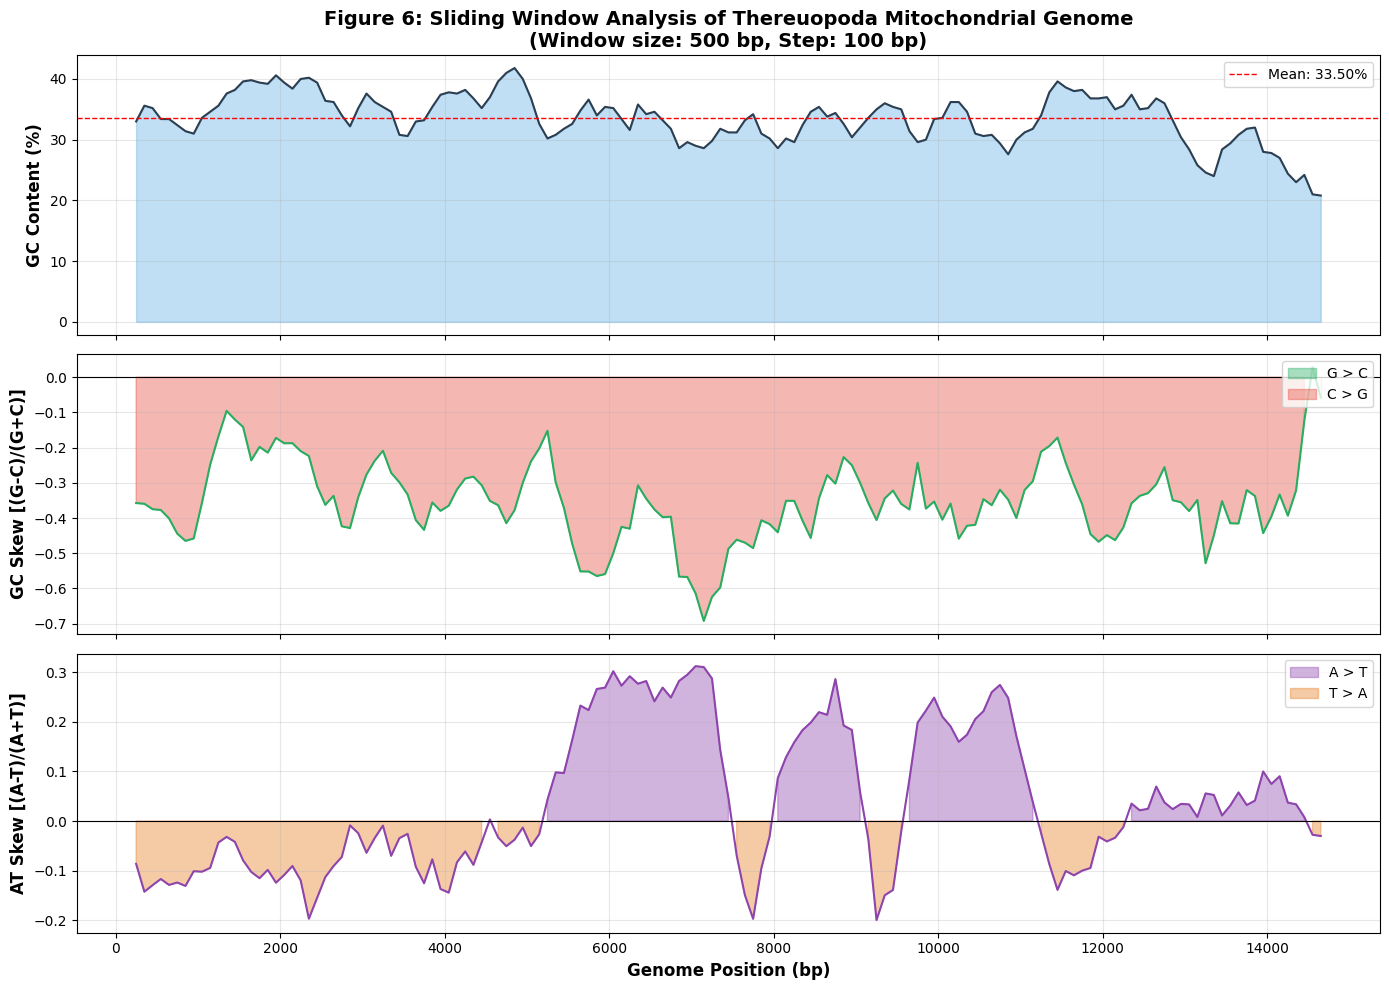

In [8]:
# ==============================================================
# Figure 6: Sliding Window Analysis - GC Content and Skew
# ==============================================================

def sliding_window_analysis(sequence, window_size=500, step=100):
    """Calculate GC content and skew using sliding window."""
    positions = []
    gc_content = []
    gc_skew = []
    at_skew = []
    
    for i in range(0, len(sequence) - window_size + 1, step):
        window = sequence[i:i+window_size].upper()
        
        A = window.count("A")
        T = window.count("T")
        G = window.count("G")
        C = window.count("C")
        total = A + T + G + C
        
        positions.append(i + window_size/2)
        gc_content.append((G + C) / total * 100 if total > 0 else 0)
        gc_skew.append((G - C) / (G + C) if (G + C) > 0 else 0)
        at_skew.append((A - T) / (A + T) if (A + T) > 0 else 0)
    
    return positions, gc_content, gc_skew, at_skew

# Calculate sliding window
positions, gc_cont, gc_sk, at_sk = sliding_window_analysis(str(record.seq))

# Create subplot with 3 panels
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: GC Content
ax1.plot(positions, gc_cont, color='#2c3e50', linewidth=1.5)
ax1.fill_between(positions, gc_cont, alpha=0.3, color='#3498db')
ax1.axhline(np.mean(gc_cont), color='red', linestyle='--', linewidth=1, label=f'Mean: {np.mean(gc_cont):.2f}%')
ax1.set_ylabel('GC Content (%)', fontsize=12, fontweight='bold')
ax1.set_title('Figure 6: Sliding Window Analysis of Thereuopoda Mitochondrial Genome\n(Window size: 500 bp, Step: 100 bp)', 
              fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend(loc='upper right')

# Panel 2: GC Skew
ax2.plot(positions, gc_sk, color='#27ae60', linewidth=1.5)
ax2.fill_between(positions, gc_sk, 0, where=(np.array(gc_sk)>=0), alpha=0.4, color='#27ae60', label='G > C')
ax2.fill_between(positions, gc_sk, 0, where=(np.array(gc_sk)<0), alpha=0.4, color='#e74c3c', label='C > G')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax2.set_ylabel('GC Skew [(G-C)/(G+C)]', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend(loc='upper right')

# Panel 3: AT Skew
ax3.plot(positions, at_sk, color='#8e44ad', linewidth=1.5)
ax3.fill_between(positions, at_sk, 0, where=(np.array(at_sk)>=0), alpha=0.4, color='#8e44ad', label='A > T')
ax3.fill_between(positions, at_sk, 0, where=(np.array(at_sk)<0), alpha=0.4, color='#e67e22', label='T > A')
ax3.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax3.set_ylabel('AT Skew [(A-T)/(A+T)]', fontsize=12, fontweight='bold')
ax3.set_xlabel('Genome Position (bp)', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

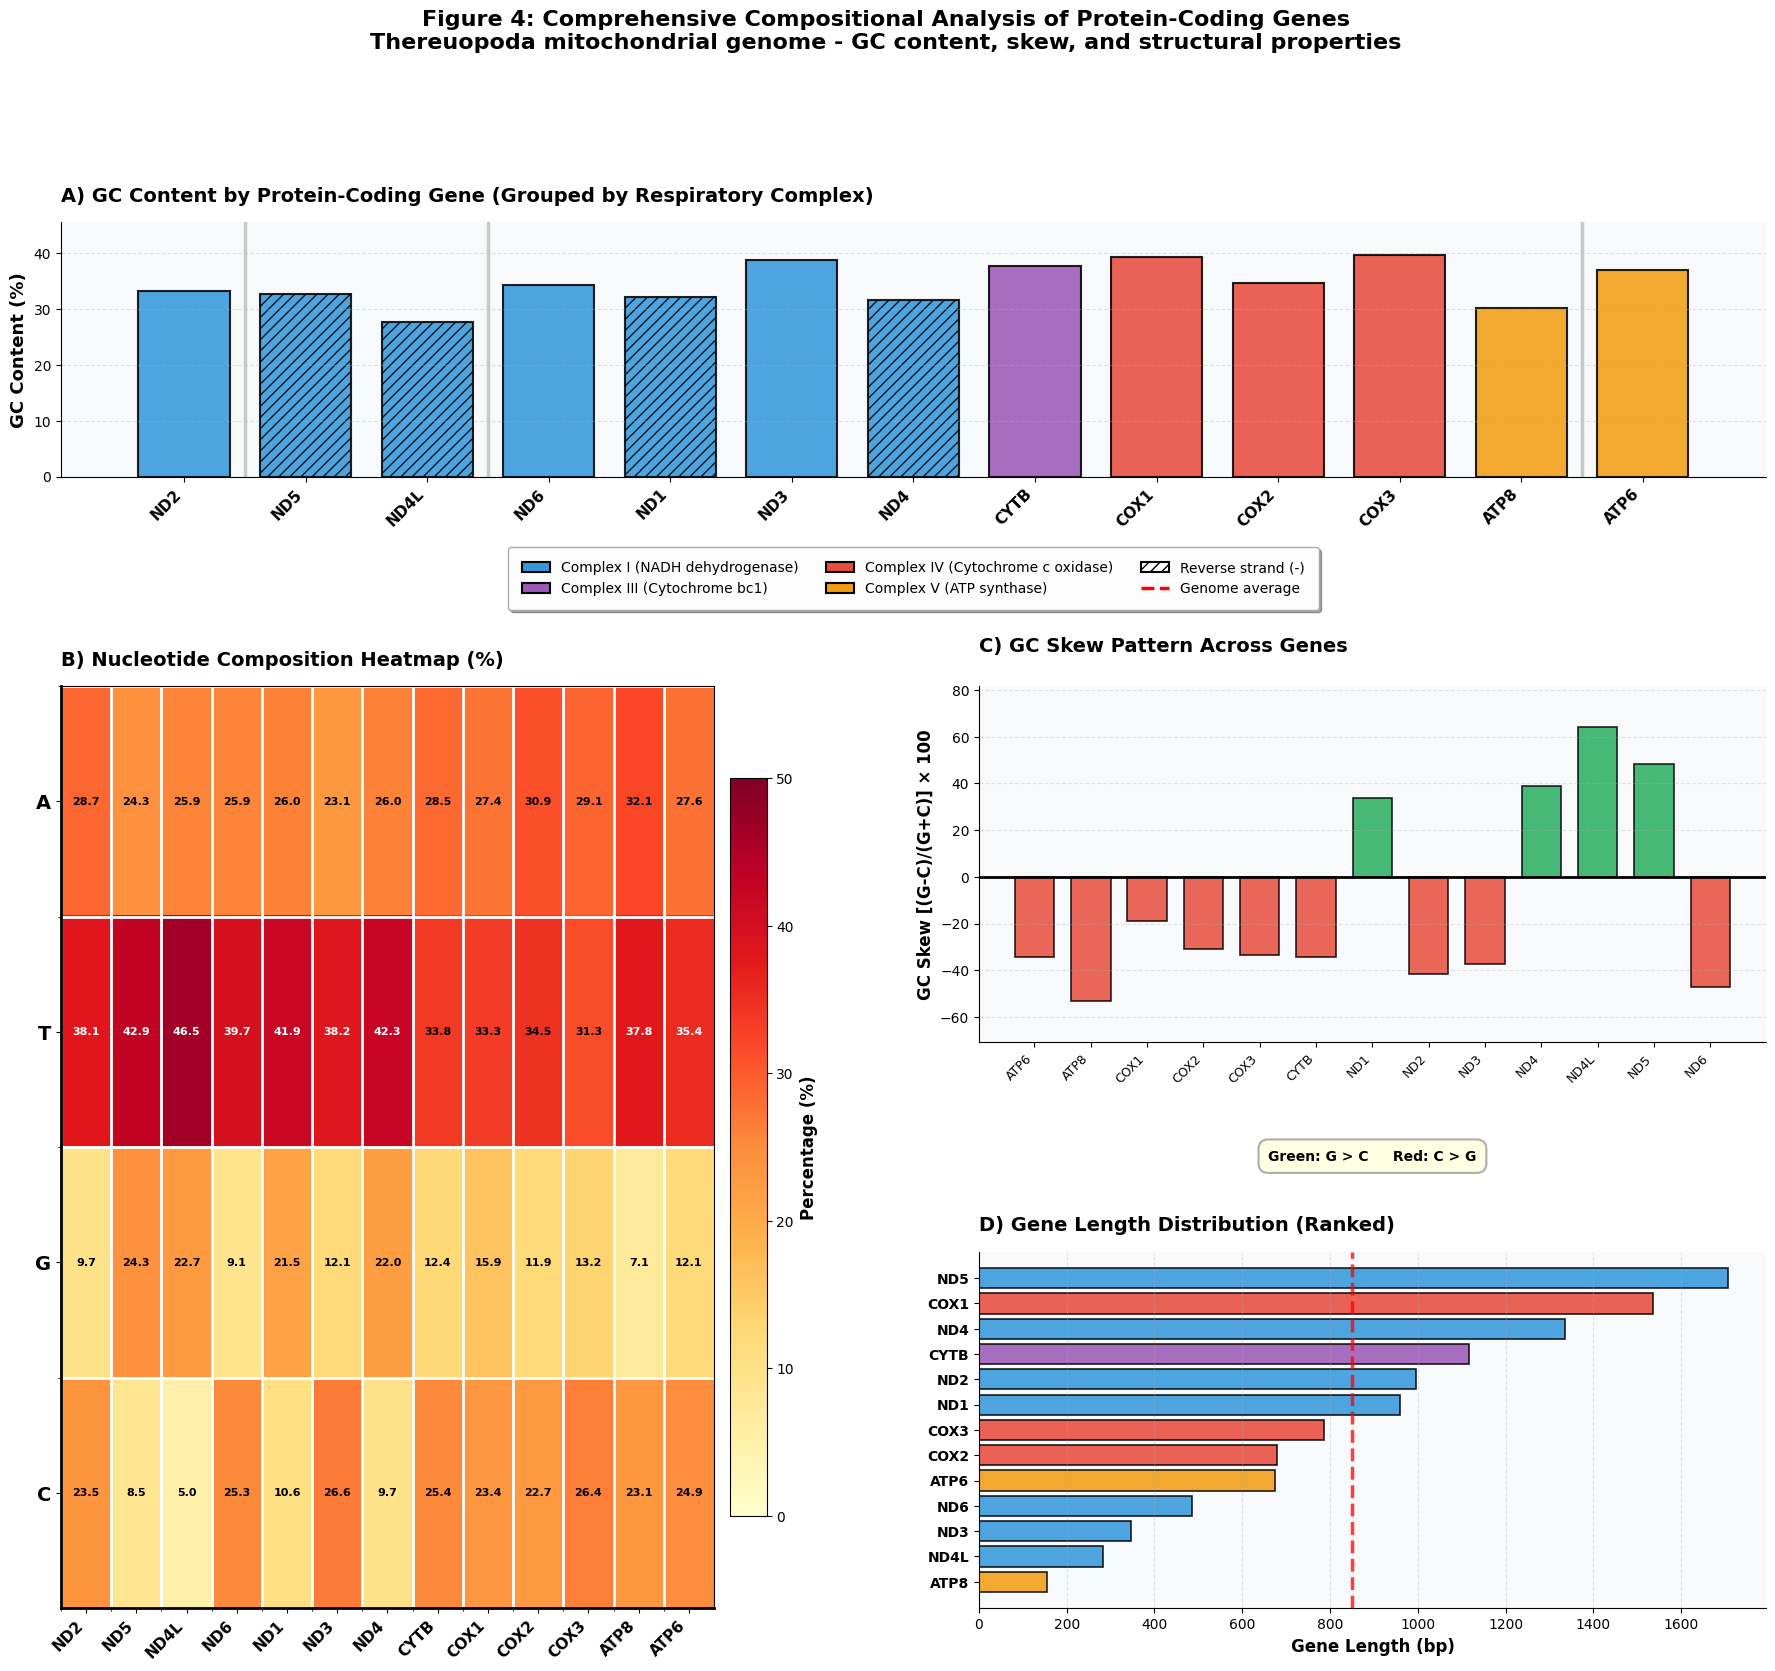


GENE COMPOSITION SUMMARY STATISTICS

Total protein-coding genes: 13
Mean GC content: 34.53% (SD: 3.74)
Mean gene length: 851 bp (SD: 483)

GC content range: 27.66% - 39.64%
Gene length range: 156 bp - 1708 bp

Genes with positive GC skew (G > C): 4
Genes with negative GC skew (C > G): 9


,Gene,Strand,Group,GC%,GC_skew,Length
0,ND2,+,Complex I,33.232932,-0.413897,996
6,ND5,-,Complex I,32.786885,0.482143,1708
7,ND4L,-,Complex I,27.659574,0.641026,282
8,ND6,+,Complex I,34.362140,-0.473054,486
9,ND1,-,Complex I,32.083333,0.337662,960
10,ND3,+,Complex I,38.728324,-0.373134,346
11,ND4,-,Complex I,31.661677,0.390071,1336
12,CYTB,+,Complex III,37.724014,-0.344418,1116
1,COX1,+,Complex IV,39.257812,-0.190713,1536
2,COX2,+,Complex IV,34.609720,-0.310638,679


In [9]:
# ==============================================================
# Figure 4: Professional Multi-Panel Gene Composition Analysis
# --------------------------------------------------------------
# Comprehensive analysis of GC content, skew, and structural properties
# ==============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import pandas as pd
import numpy as np

def base_composition(seq):
    """Return A, T, G, C counts and derived composition stats."""
    seq = seq.upper()
    A = seq.count("A")
    T = seq.count("T")
    G = seq.count("G")
    C = seq.count("C")
    total = A + T + G + C
    gc = ((G + C) / total) * 100 if total > 0 else 0
    gc_skew = (G - C) / (G + C) if (G + C) > 0 else 0
    at_skew = (A - T) / (A + T) if (A + T) > 0 else 0
    return A, T, G, C, gc, gc_skew, at_skew

# --- Extract comprehensive metrics per CDS ---
data = []
for feature in record.features:
    if feature.type == "CDS":
        gene = feature.qualifiers.get("gene", ["unknown"])[0]
        seq = feature.extract(record.seq)
        A, T, G, C, gc, gc_skew, at_skew = base_composition(seq)
        strand = "+" if feature.location.strand == 1 else "-"
        length = len(seq)
        
        # Categorize by protein complex
        if gene.startswith("ND") or gene.startswith("NAD"):
            group = "Complex I"
            group_color = '#3498db'
        elif gene.startswith(("COX", "CO")):
            group = "Complex IV"
            group_color = '#e74c3c'
        elif gene.startswith("ATP"):
            group = "Complex V"
            group_color = '#f39c12'
        elif "CYTB" in gene.upper() or "COB" in gene.upper():
            group = "Complex III"
            group_color = '#9b59b6'
        else:
            group = "Other"
            group_color = '#95a5a6'
        
        data.append({
            "Gene": gene, "GC%": gc, "GC_skew": gc_skew,
            "AT_skew": at_skew, "AT%": 100 - gc, "Length": length,
            "Strand": strand, "Group": group, "Color": group_color,
            "A": A, "T": T, "G": G, "C": C
        })

df_gc = pd.DataFrame(data).sort_values(by="Group")

# --- Create multi-panel figure with clear, well-defined areas ---
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor('white')

# Create custom gridspec for better control
# Layout: 1st row = Panel A (full width, smaller)
#         2nd-3rd rows = Panel B (left, larger) | Panels C & D (right, stacked)
gs = GridSpec(3, 4, figure=fig, hspace=0.65, wspace=0.4,
              height_ratios=[1.0, 1.4, 1.4], width_ratios=[1, 1, 1, 1])

# ============================================================
# Panel A: GC Content by Gene (Full Width, Row 1)
# ============================================================
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#f8f9fa')

# Create bar plot with complex-specific colors
bars = ax1.bar(range(len(df_gc)), df_gc["GC%"], 
               color=df_gc["Color"], edgecolor='black', 
               linewidth=1.5, alpha=0.87, width=0.75)

# Add strand pattern overlay
for idx, (i, row) in enumerate(df_gc.iterrows()):
    if row["Strand"] == "-":
        bars[idx].set_hatch('///')

# Genome average line
genome_gc = ((G + C) / total) * 100
ax1.axhline(genome_gc, color='red', linestyle='--', linewidth=2.5, 
           alpha=0.75, label=f'Genome avg: {genome_gc:.1f}%', zorder=3)

ax1.set_xticks(range(len(df_gc)))
ax1.set_xticklabels(df_gc["Gene"], rotation=45, ha='right', fontsize=11, fontweight='bold')
ax1.set_ylabel("GC Content (%)", fontsize=13, fontweight='bold')
ax1.set_title("A) GC Content by Protein-Coding Gene (Grouped by Respiratory Complex)", 
             fontsize=14, fontweight='bold', loc='left', pad=15)
ax1.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax1.set_ylim(0, max(df_gc["GC%"]) * 1.15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Add complex boundaries with more prominent lines
current_group = None
for idx, row in df_gc.iterrows():
    if row["Group"] != current_group:
        if current_group is not None:
            ax1.axvline(idx - 0.5, color='darkgray', linestyle='-', linewidth=2.5, alpha=0.6, zorder=1)
        current_group = row["Group"]

# Legend with custom positioning - positioned outside the plot area
legend_elements = [
    mpatches.Patch(facecolor='#3498db', edgecolor='black', label='Complex I (NADH dehydrogenase)', linewidth=1.5),
    mpatches.Patch(facecolor='#9b59b6', edgecolor='black', label='Complex III (Cytochrome bc1)', linewidth=1.5),
    mpatches.Patch(facecolor='#e74c3c', edgecolor='black', label='Complex IV (Cytochrome c oxidase)', linewidth=1.5),
    mpatches.Patch(facecolor='#f39c12', edgecolor='black', label='Complex V (ATP synthase)', linewidth=1.5),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label='Reverse strand (-)', linewidth=1.5),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2.5, label='Genome average')
]
ax1.legend(handles=legend_elements, loc='upper center', ncol=3, 
          fontsize=10, framealpha=0.98, edgecolor='darkgray', fancybox=True, shadow=True,
          bbox_to_anchor=(0.5, -0.25), borderpad=1)

# ============================================================
# Panel B: Nucleotide Composition Heatmap (LEFT, Large - Rows 2-3, Cols 1-2)
# ============================================================
ax4 = fig.add_subplot(gs[1:, :2])
ax4.set_facecolor('white')

# Create composition matrix
comp_matrix = df_gc[["A", "T", "G", "C"]].values.T / df_gc["Length"].values * 100

im = ax4.imshow(comp_matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=50, 
               interpolation='nearest')

ax4.set_yticks(range(4))
ax4.set_yticklabels(['A', 'T', 'G', 'C'], fontsize=14, fontweight='bold')
ax4.set_xticks(range(len(df_gc)))
ax4.set_xticklabels(df_gc["Gene"], rotation=45, ha='right', fontsize=11, fontweight='bold')
ax4.set_title("B) Nucleotide Composition Heatmap (%)", 
             fontsize=14, fontweight='bold', loc='left', pad=15)

# Add grid for better readability
ax4.set_xticks(np.arange(len(df_gc)) - 0.5, minor=True)
ax4.set_yticks(np.arange(4) - 0.5, minor=True)
ax4.grid(which='minor', color='white', linestyle='-', linewidth=2)

# Add colorbar with better positioning
cbar = plt.colorbar(im, ax=ax4, orientation='vertical', pad=0.02, shrink=0.8)
cbar.set_label('Percentage (%)', fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=10)

# Add values in cells with enhanced visibility
for i in range(4):
    for j in range(len(df_gc)):
        value = comp_matrix[i, j]
        # Choose text color based on background intensity
        text_color = 'white' if value > 35 else 'black'
        text = ax4.text(j, i, f'{value:.1f}',
                       ha="center", va="center", color=text_color, 
                       fontsize=8, fontweight='bold')

ax4.spines['top'].set_visible(True)
ax4.spines['right'].set_visible(True)
ax4.spines['left'].set_linewidth(2)
ax4.spines['bottom'].set_linewidth(2)

# ============================================================
# Panel C: GC Skew Pattern (RIGHT TOP - Row 2, Cols 3-4)
# ============================================================
ax2 = fig.add_subplot(gs[1, 2:])
ax2.set_facecolor('#f8f9fa')

# Sort by genomic position for skew pattern
df_sorted_pos = df_gc.sort_values(by="Gene")

x_pos = np.arange(len(df_sorted_pos))
colors_skew = ['#27ae60' if val > 0 else '#e74c3c' 
               for val in df_sorted_pos["GC_skew"]]

bars2 = ax2.bar(x_pos, df_sorted_pos["GC_skew"] * 100, 
                color=colors_skew, edgecolor='black', linewidth=1.2, 
                alpha=0.85, width=0.7)

ax2.axhline(0, color='black', linestyle='-', linewidth=2)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(df_sorted_pos["Gene"], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel("GC Skew [(G-C)/(G+C)] × 100", fontsize=12, fontweight='bold')
ax2.set_title("C) GC Skew Pattern Across Genes", 
             fontsize=14, fontweight='bold', loc='left', pad=25)
ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Adjust top margin to prevent title overlap
ax2.margins(y=0.15)

# Add reference box below plot - same style as Panel A legend
ax2.text(0.5, -0.30, 'Green: G > C     Red: C > G', 
        transform=ax2.transAxes, ha='center', va='top',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='lightyellow', 
                 edgecolor='darkgray', alpha=0.95, linewidth=1.5))

# ============================================================
# Panel D: Gene Length Distribution (RIGHT BOTTOM - Row 3, Cols 3-4)
# ============================================================
ax3 = fig.add_subplot(gs[2, 2:])
ax3.set_facecolor('#f8f9fa')

# Sort by length
df_sorted_len = df_gc.sort_values(by="Length", ascending=False)

bars3 = ax3.barh(range(len(df_sorted_len)), df_sorted_len["Length"],
                 color=df_sorted_len["Color"], edgecolor='black', 
                 linewidth=1.2, alpha=0.87)

ax3.set_yticks(range(len(df_sorted_len)))
ax3.set_yticklabels(df_sorted_len["Gene"], fontsize=10, fontweight='bold')
ax3.set_xlabel("Gene Length (bp)", fontsize=12, fontweight='bold')
ax3.set_title("D) Gene Length Distribution (Ranked)", 
             fontsize=14, fontweight='bold', loc='left', pad=15)
ax3.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
ax3.invert_yaxis()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Add mean line (without legend)
mean_len = df_gc["Length"].mean()
ax3.axvline(mean_len, color='red', linestyle='--', linewidth=2.5, 
           alpha=0.75, zorder=3)

# ============================================================
# Main title with enhanced styling
# ============================================================
fig.suptitle('Figure 4: Comprehensive Compositional Analysis of Protein-Coding Genes\n' +
             'Thereuopoda mitochondrial genome - GC content, skew, and structural properties', 
             fontsize=16, fontweight='bold', y=0.998)

plt.show()

# ============================================================
# Summary statistics
# ============================================================
print("\n" + "="*80)
print("GENE COMPOSITION SUMMARY STATISTICS")
print("="*80)
print(f"\nTotal protein-coding genes: {len(df_gc)}")
print(f"Mean GC content: {df_gc['GC%'].mean():.2f}% (SD: {df_gc['GC%'].std():.2f})")
print(f"Mean gene length: {df_gc['Length'].mean():.0f} bp (SD: {df_gc['Length'].std():.0f})")
print(f"\nGC content range: {df_gc['GC%'].min():.2f}% - {df_gc['GC%'].max():.2f}%")
print(f"Gene length range: {df_gc['Length'].min()} bp - {df_gc['Length'].max()} bp")
print(f"\nGenes with positive GC skew (G > C): {sum(df_gc['GC_skew'] > 0)}")
print(f"Genes with negative GC skew (C > G): {sum(df_gc['GC_skew'] < 0)}")
print("="*80)

# Display detailed table
df_gc[["Gene", "Strand", "Group", "GC%", "GC_skew", "Length"]]


Saved files:
  Figure15_CircularGenome_Improved.svg
  Figure15_CircularGenome_Improved.png
  Figure15_CircularGenome_Improved.jpg


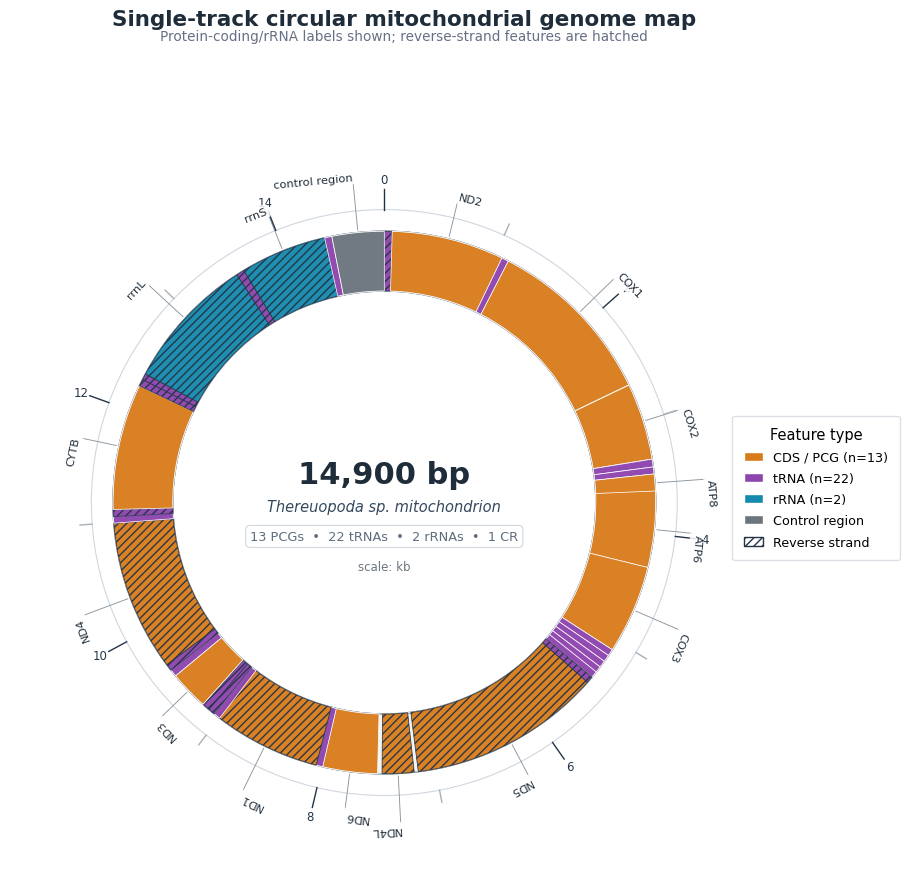

In [12]:
# ==============================================================
# Improved Single-Track Circular Mitochondrial Genome Map
# Run directly in Jupyter
# ==============================================================

%matplotlib inline

import math
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
from Bio import SeqIO


# -----------------------------
# Input GenBank file
# -----------------------------
# Change this path if your file is in another folder.
gb_file = "sequence_M3509A_corrected.gb"

# If you already loaded `record` earlier, this will keep using it.
try:
    record
except NameError:
    record = SeqIO.read(gb_file, "genbank")


# -----------------------------
# Plot settings
# -----------------------------
FEATURE_COLORS = {
    "CDS": "#D87C1B",      # protein-coding genes
    "tRNA": "#8E44AD",     # tRNAs
    "rRNA": "#168AAD",     # rRNAs
    "D-loop": "#6C757D",   # control region
}

TRACK_INNER = 0.78
TRACK_OUTER = 1.00


def feature_name(feature):
    """Return a compact display name for a GenBank feature."""
    for key in ("gene", "label", "product", "note"):
        value = feature.qualifiers.get(key)
        if value:
            name = str(value[0])
            name = name.replace("transfer RNA-", "trn")
            name = name.replace("cytochrome c oxidase subunit", "cox")
            name = name.replace("NADH dehydrogenase subunit", "nad")
            name = name.replace("ATP synthase F0 subunit", "atp")
            name = name.replace("cytochrome b", "cob")
            return name

    if feature.type == "D-loop":
        return "CR"

    return feature.type


def pos_to_angle(pos, genome_len):
    """Map genome coordinate to degrees: 0 bp at top, clockwise direction."""
    return 90.0 - 360.0 * (pos / genome_len)


def xy(angle_deg, radius):
    """Convert polar coordinate to x, y."""
    rad = math.radians(angle_deg)
    return radius * math.cos(rad), radius * math.sin(rad)


def simple_parts(feature, genome_len):
    """
    Yield start/end intervals.
    Handles compound locations and rare origin-spanning features.
    """
    parts = getattr(feature.location, "parts", [feature.location])

    for part in parts:
        start = int(part.start)
        end = int(part.end)

        if start < end:
            yield start, end
        else:
            yield start, genome_len
            yield 0, end


def add_arc_feature(ax, start, end, genome_len, color, strand):
    """Draw one feature as an annular wedge."""
    theta1 = pos_to_angle(end, genome_len)
    theta2 = pos_to_angle(start, genome_len)

    edgecolor = "#243447" if strand == -1 else "white"
    hatch = "////" if strand == -1 else None

    wedge = Wedge(
        (0, 0),
        TRACK_OUTER,
        theta1,
        theta2,
        width=TRACK_OUTER - TRACK_INNER,
        facecolor=color,
        edgecolor=edgecolor,
        linewidth=0.55,
        alpha=0.96,
        hatch=hatch,
        zorder=3,
    )

    ax.add_patch(wedge)


def add_label(ax, start, end, genome_len, label, label_index):
    """Add outside label with leader line."""
    mid = (start + end) / 2
    angle = pos_to_angle(mid, genome_len)

    # Stagger labels slightly to reduce overlap.
    label_radius = 1.16 + 0.045 * (label_index % 2)

    x0, y0 = xy(angle, TRACK_OUTER + 0.01)
    x1, y1 = xy(angle, label_radius - 0.02)
    xt, yt = xy(angle, label_radius)

    ha = "left" if xt >= 0 else "right"

    rotation = angle - 90
    if 90 < angle < 270:
        rotation += 180

    ax.plot(
        [x0, x1],
        [y0, y1],
        color="#8A959E",
        lw=0.65,
        zorder=2,
    )

    ax.text(
        xt,
        yt,
        label,
        ha=ha,
        va="center",
        fontsize=8.2,
        color="#1F2D3A",
        rotation=rotation,
        rotation_mode="anchor",
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
        zorder=5,
    )


def plot_circular_genome(record, output_prefix="Figure15_CircularGenome_Improved"):
    genome_len = len(record.seq)

    wanted_types = {"CDS", "tRNA", "rRNA", "D-loop"}
    features = [f for f in record.features if f.type in wanted_types]
    counts = Counter(f.type for f in features)

    fig, ax = plt.subplots(figsize=(10.5, 10.5))
    ax.set_aspect("equal")
    ax.axis("off")

    # Extra room on right for legend.
    ax.set_xlim(-1.38, 1.62)
    ax.set_ylim(-1.34, 1.34)

    # Background gene track.
    base_ring = Wedge(
        (0, 0),
        TRACK_OUTER,
        0,
        360,
        width=TRACK_OUTER - TRACK_INNER,
        facecolor="#F2F4F5",
        edgecolor="#243447",
        linewidth=1.1,
        zorder=1,
    )
    ax.add_patch(base_ring)

    # Clean guide rings.
    for radius, lw in [
        (TRACK_INNER, 1.0),
        (TRACK_OUTER, 1.0),
        (1.08, 0.8),
    ]:
        ax.add_patch(
            plt.Circle(
                (0, 0),
                radius,
                facecolor="none",
                edgecolor="#D0D7DE",
                lw=lw,
                zorder=1,
            )
        )

    # Draw features.
    labelable_features = []

    for feature in features:
        color = FEATURE_COLORS.get(feature.type, "#ADB5BD")
        strand = feature.location.strand

        for start, end in simple_parts(feature, genome_len):
            add_arc_feature(
                ax=ax,
                start=start,
                end=end,
                genome_len=genome_len,
                color=color,
                strand=strand,
            )

            # Label only larger/important features.
            # tRNAs are usually too many and make the plot crowded.
            if feature.type in {"CDS", "rRNA", "D-loop"}:
                labelable_features.append(
                    (start, end, feature_name(feature))
                )

    # Kilobase ticks.
    minor_step = 1000
    major_step = 2000

    for pos in range(0, genome_len + 1, minor_step):
        angle = pos_to_angle(pos % genome_len, genome_len)

        tick_len = 0.075 if pos % major_step == 0 else 0.045

        x0, y0 = xy(angle, 1.08)
        x1, y1 = xy(angle, 1.08 + tick_len)

        ax.plot(
            [x0, x1],
            [y0, y1],
            color="#243447" if pos % major_step == 0 else "#A7B0B7",
            lw=1.0,
            zorder=4,
        )

        if pos % major_step == 0 and pos < genome_len:
            xt, yt = xy(angle, 1.19)
            ax.text(
                xt,
                yt,
                f"{pos // 1000}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="#243447",
            )

    # Add labels.
    for i, (start, end, label) in enumerate(labelable_features):
        add_label(
            ax=ax,
            start=start,
            end=end,
            genome_len=genome_len,
            label=label,
            label_index=i,
        )

    # Center annotation.
    ax.text(
        0,
        0.105,
        f"{genome_len:,} bp",
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color="#1F2D3A",
    )

    title = record.description.replace(", complete genome", "")

    ax.text(
        0,
        -0.015,
        title,
        ha="center",
        va="center",
        fontsize=10.5,
        fontstyle="italic",
        color="#34495E",
    )

    ax.text(
        0,
        -0.125,
        f"{counts['CDS']} PCGs  •  {counts['tRNA']} tRNAs  •  {counts['rRNA']} rRNAs  •  {counts['D-loop']} CR",
        ha="center",
        va="center",
        fontsize=9.3,
        color="#5D6D7E",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="#D0D7DE",
            linewidth=0.8,
        ),
    )

    ax.text(
        0,
        -0.235,
        "scale: kb",
        ha="center",
        va="center",
        fontsize=8.5,
        color="#6C757D",
    )

    # Legend.
    legend_items = [
        mpatches.Patch(
            facecolor=FEATURE_COLORS["CDS"],
            edgecolor="white",
            label=f"CDS / PCG (n={counts['CDS']})",
        ),
        mpatches.Patch(
            facecolor=FEATURE_COLORS["tRNA"],
            edgecolor="white",
            label=f"tRNA (n={counts['tRNA']})",
        ),
        mpatches.Patch(
            facecolor=FEATURE_COLORS["rRNA"],
            edgecolor="white",
            label=f"rRNA (n={counts['rRNA']})",
        ),
        mpatches.Patch(
            facecolor=FEATURE_COLORS["D-loop"],
            edgecolor="white",
            label="Control region",
        ),
        mpatches.Patch(
            facecolor="white",
            edgecolor="#243447",
            hatch="////",
            label="Reverse strand",
        ),
    ]

    legend = ax.legend(
        handles=legend_items,
        loc="center left",
        bbox_to_anchor=(0.88, 0.52),
        frameon=True,
        title="Feature type",
        fontsize=9.2,
        title_fontsize=10.5,
        borderpad=0.9,
        labelspacing=0.65,
        handlelength=1.5,
    )

    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("#D0D7DE")
    legend.get_frame().set_linewidth(0.9)

    # Figure title.
    fig.suptitle(
        "Single-track circular mitochondrial genome map",
        y=0.965,
        fontsize=15.5,
        fontweight="bold",
        color="#1F2D3A",
    )

    fig.text(
        0.5,
        0.935,
        "Protein-coding/rRNA labels shown; reverse-strand features are hatched",
        ha="center",
        fontsize=9.8,
        color="#667085",
    )

    # Save outputs.
    out = Path(output_prefix)

    fig.savefig(out.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(out.with_suffix(".png"), dpi=450, bbox_inches="tight", facecolor="white")
    fig.savefig(out.with_suffix(".jpg"), dpi=600, bbox_inches="tight", facecolor="white")

    print("Saved files:")
    print(f"  {out.with_suffix('.svg')}")
    print(f"  {out.with_suffix('.png')}")
    print(f"  {out.with_suffix('.jpg')}")

    return fig, ax


# -----------------------------
# Run plot
# -----------------------------
fig, ax = plot_circular_genome(
    record,
    output_prefix="Figure15_CircularGenome_Improved"
)

plt.show()